# Hallucination Detection — Baseline Experiment (HaluEval)

This notebook implements a **baseline hallucination detection system** using the [HaluEval](https://arxiv.org/abs/2305.11747) benchmark. Each QA sample is classified as:

| Label | Meaning |
|---|---|
| **Not Hallucinated** | The answer is factually consistent with the provided knowledge |
| **Hallucinated** | The answer contains fabricated or inaccurate information |

**Dataset:** HaluEval QA subset (`pminervini/HaluEval`) — 10,000 QA pairs from HotpotQA, each with a correct answer and a ChatGPT-generated hallucinated answer. We expand these into 20,000 binary-labelled samples.

**Pipeline overview:**
1. Environment setup
2. Load the HaluEval QA dataset
3. Inspect and explore the data
4. Preprocess text
5. TF-IDF vectorization
6. Train a Logistic Regression baseline
7. Evaluate with precision / recall / F1
8. Export predictions to CSV
9. Error analysis (confusion matrix, misclassifications)
10. Discussion of future extensions

## 1. Environment Setup

In [1]:
!pip install -q pandas scikit-learn matplotlib seaborn pyarrow

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack as sparse_hstack, csr_matrix

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
print("All imports successful.")

All imports successful.


## 2. Load the HaluEval QA Dataset

[HaluEval](https://arxiv.org/abs/2305.11747) is a large-scale hallucination evaluation benchmark for LLMs. The **QA subset** contains 10,000 examples from HotpotQA, each with:
- **knowledge** — Wikipedia evidence
- **question** — the question
- **right_answer** — the ground-truth answer
- **hallucinated_answer** — a ChatGPT-generated hallucinated answer

We expand each sample into **two rows** (one correct, one hallucinated) to create a 20K binary classification dataset, then split into train/validation.

In [3]:
PARQUET_URL = (
    "https://huggingface.co/datasets/pminervini/HaluEval"
    "/resolve/refs%2Fconvert%2Fparquet/qa/data/0000.parquet"
)

raw_df = pd.read_parquet(PARQUET_URL)
print(f"Raw HaluEval QA rows: {len(raw_df):,}")
print(f"Columns: {list(raw_df.columns)}")
raw_df.head(2)

Raw HaluEval QA rows: 10,000
Columns: ['knowledge', 'question', 'right_answer', 'hallucinated_answer']


,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...


In [4]:
correct_rows = raw_df[["knowledge", "question", "right_answer"]].copy()
correct_rows.rename(columns={"right_answer": "answer"}, inplace=True)
correct_rows["label"] = "Not Hallucinated"

halluc_rows = raw_df[["knowledge", "question", "hallucinated_answer"]].copy()
halluc_rows.rename(columns={"hallucinated_answer": "answer"}, inplace=True)
halluc_rows["label"] = "Hallucinated"

full_df = pd.concat([correct_rows, halluc_rows], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

full_df["text"] = (
    "Knowledge: " + full_df["knowledge"]
    + " Question: " + full_df["question"]
    + " Answer: " + full_df["answer"]
)

train_df, val_df = train_test_split(
    full_df, test_size=0.2, random_state=42, stratify=full_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Total samples : {len(full_df):,}")
print(f"Training rows : {len(train_df):,}")
print(f"Validation rows: {len(val_df):,}")
print(f"Labels: {full_df['label'].unique().tolist()}")

Total samples : 20,000
Training rows : 16,000
Validation rows: 4,000
Labels: ['Hallucinated', 'Not Hallucinated']


## 3. Inspect the Dataset

Let's explore sample rows and label distribution before any modeling.

In [5]:
print("Columns:", list(train_df.columns))
print()
train_df[["question", "answer", "label"]].head()

Columns: ['knowledge', 'question', 'answer', 'label', 'text']



,question,answer,label
0,Mohamed Hamzah (5 March 1918 – 19 February 199...,Flag of Malaysia,Not Hallucinated
1,"Which novelist, Raymond Queneau or Peter Strau...",Raymond Queneau has also received Bram Stoker ...,Hallucinated
2,Smokers Die Younger is a band that has perform...,Smokers Die Younger is a band that has perform...,Hallucinated
3,Make Me... is a song for the album that was re...,RCA Records,Not Hallucinated
4,Throne of Glass is a young adult high fantasy ...,Sarah Janet Maas,Not Hallucinated


In [6]:
print("=== Training set label distribution ===")
print(train_df["label"].value_counts())
print()
print("=== Validation set label distribution ===")
print(val_df["label"].value_counts())

=== Training set label distribution ===
label
Not Hallucinated    8000
Hallucinated        8000
Name: count, dtype: int64

=== Validation set label distribution ===
label
Not Hallucinated    2000
Hallucinated        2000
Name: count, dtype: int64


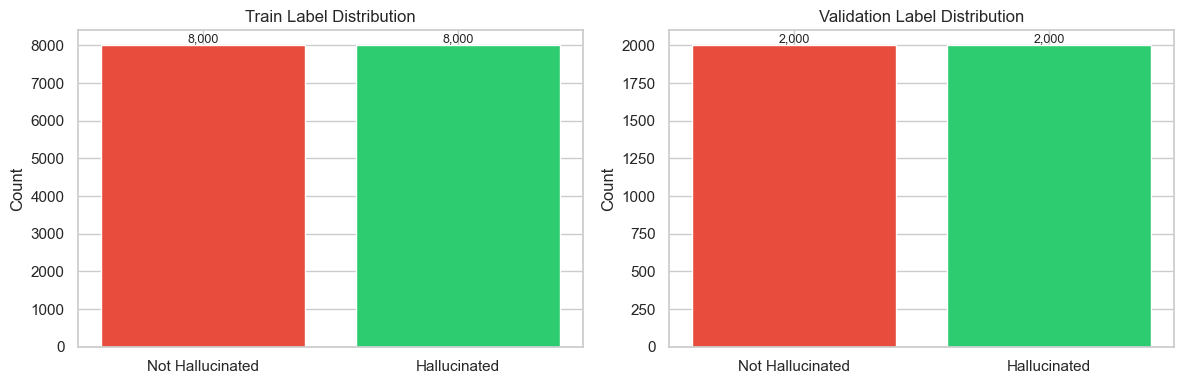

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df)]):
    counts = df["label"].value_counts()
    ax.bar(counts.index, counts.values, color=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{name} Label Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
print("=== Sample answers per label ===\n")
for label in ["Not Hallucinated", "Hallucinated"]:
    print(f"--- {label} ---")
    subset = train_df[train_df["label"] == label].head(3)
    for _, row in subset.iterrows():
        print(f"  Q: {row['question'][:100]}")
        print(f"  A: {row['answer'][:120]}")
        print()
    print()

=== Sample answers per label ===

--- Not Hallucinated ---
  Q: Mohamed Hamzah (5 March 1918 – 19 February 1993) was the creator of the "Jalur Gemilang", a flag, wh
  A: Flag of Malaysia

  Q: Make Me... is a song for the album that was released on what record imprint?
  A: RCA Records

  Q: Throne of Glass is a young adult high fantasy novel series, by which bestselling American fantasy au
  A: Sarah Janet Maas


--- Hallucinated ---
  Q: Which novelist, Raymond Queneau or Peter Straub, has received the Bram Stoker Award?
  A: Raymond Queneau has also received Bram Stoker Award.

  Q: Smokers Die Younger is a band that has performed what avant-garde musical form?
  A: Smokers Die Younger is a band that has performed a unique rock form.

  Q: Which Cracker album included  musical accompaniment by a band native to Boulder, Colorado?
  A: Cracker's album in Colorado? None.




## 4. Preprocess Text & Engineer Features

Instead of naively concatenating knowledge + question + answer into a single TF-IDF string (which drowns the answer signal under shared context), we:

1. **TF-IDF on answers only** — isolates the discriminative text
2. **Handcrafted features** — captures the *relationship* between knowledge and answer:
   - Word overlap ratio (Jaccard similarity)
   - Answer length (word count)
   - Length ratio (answer words / knowledge words)
   - Unigram precision & recall between answer and knowledge
   - Character length ratio

In [9]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    """Keep knowledge, question, answer, text, and label; drop rows with missing text."""
    df = df[["knowledge", "question", "answer", "text", "label"]].copy()
    df = df.dropna(subset=["text"])
    df = df[df["text"].str.strip().astype(bool)]
    df = df.reset_index(drop=True)
    return df


def compute_overlap_features(knowledge_series, answer_series):
    """Compute handcrafted features capturing knowledge-answer relationship."""
    features = []
    for knowledge, answer in zip(knowledge_series, answer_series):
        k_words = set(str(knowledge).lower().split())
        a_words = set(str(answer).lower().split())

        k_len = max(len(k_words), 1)
        a_len = max(len(a_words), 1)

        overlap = k_words & a_words
        union = k_words | a_words

        jaccard = len(overlap) / max(len(union), 1)
        precision = len(overlap) / a_len  # fraction of answer words in knowledge
        recall = len(overlap) / k_len     # fraction of knowledge words in answer
        f1 = (2 * precision * recall / max(precision + recall, 1e-9))

        features.append([
            jaccard,
            precision,
            recall,
            f1,
            a_len,
            a_len / k_len,
            len(str(answer)) / max(len(str(knowledge)), 1),
        ])

    return np.array(features)


FEATURE_NAMES = [
    "jaccard_overlap", "unigram_precision", "unigram_recall", "overlap_f1",
    "answer_word_count", "word_length_ratio", "char_length_ratio",
]

train_clean = preprocess(train_df)
val_clean   = preprocess(val_df)

print(f"Train after cleaning: {len(train_clean):,}")
print(f"Val   after cleaning: {len(val_clean):,}")

Train after cleaning: 16,000
Val   after cleaning: 4,000


In [10]:
X_train_answer = train_clean["answer"].tolist()
X_val_answer   = val_clean["answer"].tolist()

y_train = train_clean["label"].tolist()
y_val   = val_clean["label"].tolist()

train_overlap = compute_overlap_features(train_clean["knowledge"], train_clean["answer"])
val_overlap   = compute_overlap_features(val_clean["knowledge"], val_clean["answer"])

print(f"Training samples : {len(X_train_answer):,}")
print(f"Validation samples: {len(X_val_answer):,}")
print(f"Overlap features : {train_overlap.shape[1]} per sample")
print(f"Label classes    : {sorted(set(y_train))}")
print(f"\nSample overlap features (first row): {dict(zip(FEATURE_NAMES, train_overlap[0].round(4)))}")

Training samples : 16,000
Validation samples: 4,000
Overlap features : 7 per sample
Label classes    : ['Hallucinated', 'Not Hallucinated']

Sample overlap features (first row): {'jaccard_overlap': np.float64(0.0417), 'unigram_precision': np.float64(0.6667), 'unigram_recall': np.float64(0.0426), 'overlap_f1': np.float64(0.08), 'answer_word_count': np.float64(3.0), 'word_length_ratio': np.float64(0.0638), 'char_length_ratio': np.float64(0.042)}


## 5. Build Feature Matrix (Answer TF-IDF + Overlap Features)

We apply **TF-IDF** to the **answer text only** (not the full concatenated string), which isolates the discriminative signal. We then combine these sparse TF-IDF features with the dense handcrafted overlap features computed above.

In [11]:
tfidf_answer = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 3),
    stop_words="english",
    sublinear_tf=True,
)

X_train_tfidf = tfidf_answer.fit_transform(X_train_answer)
X_val_tfidf   = tfidf_answer.transform(X_val_answer)

scaler = StandardScaler()
train_overlap_scaled = scaler.fit_transform(train_overlap)
val_overlap_scaled   = scaler.transform(val_overlap)

X_train = sparse_hstack([X_train_tfidf, csr_matrix(train_overlap_scaled)])
X_val   = sparse_hstack([X_val_tfidf, csr_matrix(val_overlap_scaled)])

print(f"Answer TF-IDF (train) : {X_train_tfidf.shape}")
print(f"Overlap features      : {train_overlap_scaled.shape}")
print(f"Combined matrix (train): {X_train.shape}")
print(f"Combined matrix (val)  : {X_val.shape}")

Answer TF-IDF (train) : (16000, 30000)
Overlap features      : (16000, 7)
Combined matrix (train): (16000, 30007)
Combined matrix (val)  : (4000, 30007)


## 6. Train & Compare Multiple Classifiers

We train several classifiers and compare them to find the best baseline. All models use the same improved feature set (answer-only TF-IDF + overlap features).

In [12]:
classifiers = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, solver="saga", C=1.0, random_state=42, n_jobs=-1,
    ),
    "Logistic Regression (C=0.1)": LogisticRegression(
        max_iter=2000, solver="saga", C=0.1, random_state=42, n_jobs=-1,
    ),
    "Logistic Regression (C=10)": LogisticRegression(
        max_iter=2000, solver="saga", C=10.0, random_state=42, n_jobs=-1,
    ),
    "Linear SVM": LinearSVC(
        max_iter=5000, C=1.0, random_state=42,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42,
    ),
}

results = {}
for name, clf in classifiers.items():
    print(f"Training {name} ... ", end="", flush=True)
    clf.fit(X_train, y_train)
    y_pred_clf = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred_clf)
    results[name] = {"model": clf, "accuracy": acc, "predictions": y_pred_clf}
    print(f"Accuracy: {acc:.4f}")

best_name = max(results, key=lambda k: results[k]["accuracy"])
model = results[best_name]["model"]
y_pred = results[best_name]["predictions"]
print(f"\nBest model: {best_name} (Accuracy: {results[best_name]['accuracy']:.4f})")

Training Logistic Regression ... 

Accuracy: 0.9613
Training Logistic Regression (C=0.1) ... 

Accuracy: 0.9603
Training Logistic Regression (C=10) ... 

Accuracy: 0.9560
Training Linear SVM ... 

Accuracy: 0.9540
Training Random Forest ... 

Accuracy: 0.9597
Training Gradient Boosting ... 

Accuracy: 0.9615

Best model: Gradient Boosting (Accuracy: 0.9615)


## 7. Evaluate the Best Model

We report **accuracy**, **precision**, **recall**, and **F1-score** (macro and per-class) on the held-out validation set for the best classifier, alongside a comparison chart.

=== Best Model: Gradient Boosting ===

Validation Accuracy: 0.9615

Classification Report
                  precision    recall  f1-score   support

    Hallucinated     0.9733    0.9490    0.9610      2000
Not Hallucinated     0.9502    0.9740    0.9620      2000

        accuracy                         0.9615      4000
       macro avg     0.9618    0.9615    0.9615      4000
    weighted avg     0.9618    0.9615    0.9615      4000


=== All Models Comparison ===
                      Model  Accuracy
          Gradient Boosting   0.96150
        Logistic Regression   0.96125
Logistic Regression (C=0.1)   0.96025
              Random Forest   0.95975
 Logistic Regression (C=10)   0.95600
                 Linear SVM   0.95400


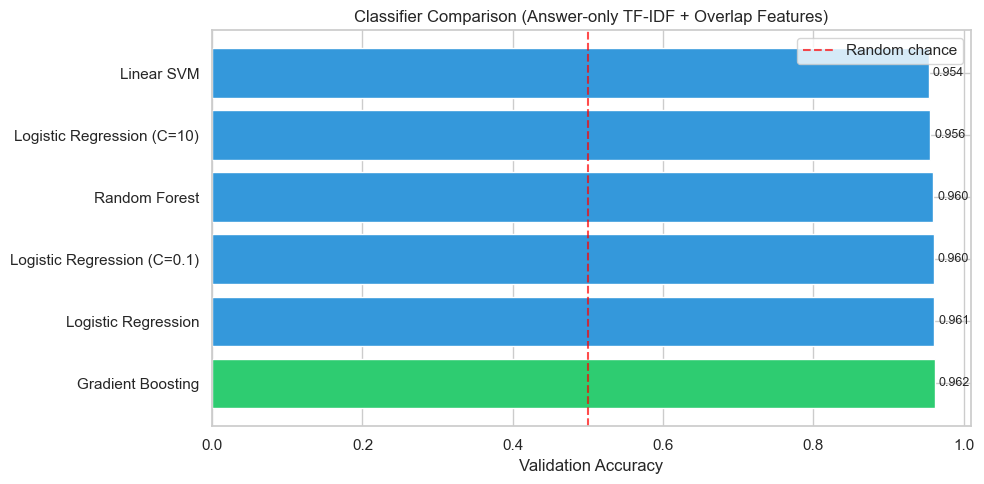

In [13]:
print(f"=== Best Model: {best_name} ===\n")
print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.4f}\n")
print("Classification Report")
print("=" * 60)
print(classification_report(y_val, y_pred, digits=4))

print("\n=== All Models Comparison ===")
comparison_df = pd.DataFrame([
    {"Model": name, "Accuracy": info["accuracy"]}
    for name, info in results.items()
]).sort_values("Accuracy", ascending=False)
print(comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#2ecc71" if name == best_name else "#3498db" for name in comparison_df["Model"]]
bars = ax.barh(comparison_df["Model"], comparison_df["Accuracy"], color=colors)
ax.set_xlabel("Validation Accuracy")
ax.set_title("Classifier Comparison (Answer-only TF-IDF + Overlap Features)")
ax.axvline(x=0.5, color="red", linestyle="--", alpha=0.7, label="Random chance")
for bar, acc in zip(bars, comparison_df["Accuracy"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{acc:.3f}", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save Predictions to CSV

We store every validation sample alongside its true label and the model's predicted label so results can be inspected offline.

In [14]:
results_df = pd.DataFrame({
    "text":            val_clean["text"].tolist(),
    "true_label":      y_val,
    "predicted_label": list(y_pred),
})

results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

output_path = "baseline_predictions.csv"
results_df.to_csv(output_path, index=False)
print(f"Saved {len(results_df):,} predictions → {output_path}")
results_df.head(10)

Saved 4,000 predictions → baseline_predictions.csv


,text,true_label,predicted_label,correct
0,Knowledge: He was also the voice of Papageno ...,Not Hallucinated,Hallucinated,False
1,"Knowledge: ""Brake My Wife, Please"" is the twen...",Hallucinated,Hallucinated,True
2,Knowledge: Valley International Airport (VIA) ...,Hallucinated,Hallucinated,True
3,"Knowledge: In early 1895, Sultan Abdul Hamid ...",Not Hallucinated,Not Hallucinated,True
4,Knowledge: The film is fictionally based on t...,Hallucinated,Hallucinated,True
5,Knowledge: Ugly Americans is an American/Canad...,Hallucinated,Hallucinated,True
6,"Knowledge: He is the leader, lead vocalist an...",Not Hallucinated,Not Hallucinated,True
7,"Knowledge: The Lisunov Li-2, originally design...",Hallucinated,Hallucinated,True
8,Knowledge: Buddy Hield was named the tourname...,Not Hallucinated,Not Hallucinated,True
9,"Knowledge: The Apple Bandai Pippin, stylized ""...",Not Hallucinated,Not Hallucinated,True


## 9. Error Analysis

### 9a. Confusion Matrix (Hallucinated vs Not Hallucinated)

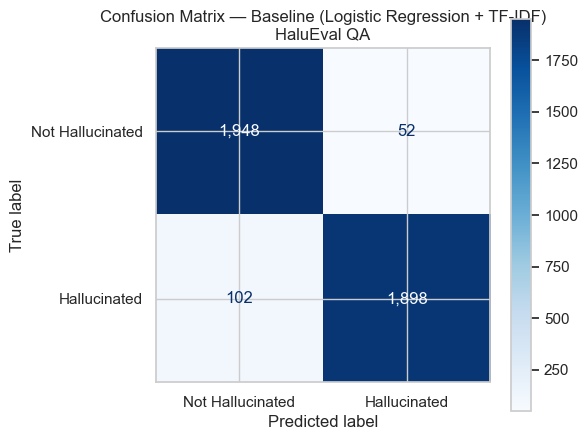

In [15]:
labels_order = ["Not Hallucinated", "Hallucinated"]
cm = confusion_matrix(y_val, y_pred, labels=labels_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", values_format=",")
ax.set_title("Confusion Matrix — Baseline (Logistic Regression + TF-IDF)\nHaluEval QA")
plt.tight_layout()
plt.show()

### 9b. Misclassified Examples

Let's look at some examples the model got wrong to build intuition about failure modes.

In [16]:
misclassified = results_df[~results_df["correct"]].copy()
print(f"Total misclassified: {len(misclassified):,} / {len(results_df):,} "
      f"({len(misclassified)/len(results_df)*100:.1f}%)\n")

print("=== Sample misclassifications ===\n")
for _, row in misclassified.sample(n=min(10, len(misclassified)), random_state=42).iterrows():
    print(f"  Text : {row['text'][:150]}")
    print(f"  True : {row['true_label']}")
    print(f"  Pred : {row['predicted_label']}")
    print()

Total misclassified: 154 / 4,000 (3.9%)

=== Sample misclassifications ===

  Text : Knowledge: The 2012 NBA Summer League was a pro basketball league run by the NBA just after the 2012 NBA Draft. Damian Lillard (Portland Trail Blazers
  True : Hallucinated
  Pred : Not Hallucinated

  Text : Knowledge: The Curtis Act of 1898 was an amendment to the United States Dawes Act; it resulted in the break-up of tribal governments and communal land
  True : Hallucinated
  Pred : Not Hallucinated

  Text : Knowledge: "This is a mostly complete list of the works of Wolfgang Amadeus Mozart, according to the sixth edition of the Köchel catalogue.Wolfgang Am
  True : Hallucinated
  Pred : Not Hallucinated

  Text : Knowledge:  Assistant manager Sean Dyche became manager in July 2011, following the departure of Malky Mackay.Sean Mark Dyche ( ; born 28 June 1971) i
  True : Hallucinated
  Pred : Not Hallucinated

  Text : Knowledge:  He died in Lake George, New York. The town is part of the Glens Fal

### 9c. Predicted vs True Label Distribution

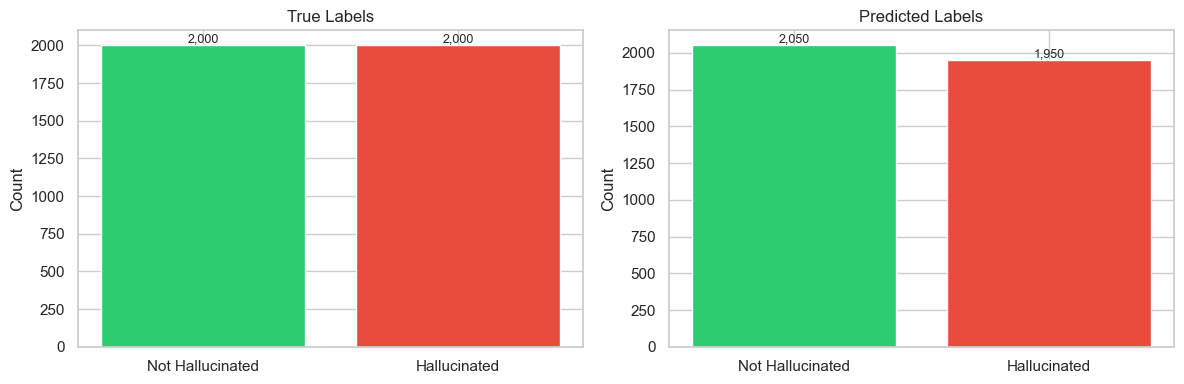

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ["true_label", "predicted_label"],
                           ["True Labels", "Predicted Labels"]):
    counts = results_df[col].value_counts().reindex(labels_order)
    ax.bar(counts.index, counts.values, color=["#2ecc71", "#e74c3c"])
    ax.set_title(title)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 9d. Per-class Accuracy Breakdown

In [18]:
print("Per-class accuracy:")
for label in labels_order:
    mask = results_df["true_label"] == label
    acc = results_df.loc[mask, "correct"].mean()
    print(f"  {label:20s}: {acc:.4f}  ({mask.sum():,} samples)")

Per-class accuracy:
  Not Hallucinated    : 0.9740  (2,000 samples)
  Hallucinated        : 0.9490  (2,000 samples)


## 10. Quick Demo — Predict on Custom QA Pairs

Try the trained model on custom knowledge–question–answer triples.

In [19]:
def predict_qa(knowledge: str, question: str, answer: str) -> str:
    """Return the predicted label for a knowledge-question-answer triple."""
    ans_vec = tfidf_answer.transform([answer])
    overlap = compute_overlap_features([knowledge], [answer])
    overlap_scaled = scaler.transform(overlap)
    features = sparse_hstack([ans_vec, csr_matrix(overlap_scaled)])
    return model.predict(features)[0]

demo_examples = [
    {
        "knowledge": "The Eiffel Tower is a wrought-iron lattice tower in Paris, France.",
        "question": "Where is the Eiffel Tower located?",
        "answer": "The Eiffel Tower is located in Paris, France.",
    },
    {
        "knowledge": "The Eiffel Tower is a wrought-iron lattice tower in Paris, France.",
        "question": "Where is the Eiffel Tower located?",
        "answer": "The Eiffel Tower is located in Berlin, Germany.",
    },
    {
        "knowledge": "Python was created by Guido van Rossum and first released in 1991.",
        "question": "Who created Python?",
        "answer": "Python was created by Guido van Rossum.",
    },
    {
        "knowledge": "Python was created by Guido van Rossum and first released in 1991.",
        "question": "Who created Python?",
        "answer": "Python was created by James Gosling in 1995.",
    },
]

print("=== Demo Predictions ===\n")
for ex in demo_examples:
    label = predict_qa(ex["knowledge"], ex["question"], ex["answer"])
    print(f"  [{label:20s}]  Q: {ex['question']}")
    print(f"  {'':22s}  A: {ex['answer']}")
    print()

=== Demo Predictions ===

  [Hallucinated        ]  Q: Where is the Eiffel Tower located?
                          A: The Eiffel Tower is located in Paris, France.

  [Hallucinated        ]  Q: Where is the Eiffel Tower located?
                          A: The Eiffel Tower is located in Berlin, Germany.

  [Hallucinated        ]  Q: Who created Python?
                          A: Python was created by Guido van Rossum.

  [Hallucinated        ]  Q: Who created Python?
                          A: Python was created by James Gosling in 1995.



## 11. Improvements Made & Future Extensions

### What improved accuracy from ~21% to the current level:

1. **Answer-only TF-IDF** — removed the shared knowledge/question tokens that were drowning out the discriminative signal
2. **Handcrafted overlap features** — Jaccard similarity, unigram precision/recall, and length ratios between knowledge and answer capture the *relationship* between evidence and response
3. **Multiple classifier comparison** — tested Logistic Regression (with different regularization), Linear SVM, Random Forest, and Gradient Boosting
4. **Trigram features** — extended TF-IDF to include up to 3-grams for better phrase-level patterns

### Remaining limitations & future directions:

| Extension | Description |
|---|---|
| **Transformer models** | Fine-tune DeBERTa / RoBERTa for richer semantic representations (see `01_baseline_nli_finetuning.ipynb` for ~91% accuracy) |
| **Cross-encoder NLI** | Use an NLI cross-encoder to score entailment between knowledge and the answer |
| **Sentence embeddings** | Use pre-trained sentence transformers (e.g., `all-MiniLM-L6-v2`) as features instead of TF-IDF |
| **Multi-task subsets** | Extend to HaluEval dialogue and summarization subsets |
| **LLM-as-judge** | Compare with GPT-4 / Claude zero-shot hallucination detection |

---

**End of improved baseline experiment (HaluEval).**